In [19]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import polars as pl
from pathlib import Path

from scipy.stats import shapiro, kstest, jarque_bera, norm
from statsmodels.stats.diagnostic import het_arch, het_white, het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant


# Time Bars

## Time Bars — анализ доходностей

Перед построением dollar bars важно понять, почему временные бары — не лучший выбор для финансового ML. Для этого анализируем статистические свойства log returns на четырёх таймфреймах: 1m, 30m, 4h, 1d.

Ключевые метрики по каждому таймфрейму:

**Kurtosis** — тяжесть хвостов распределения. У нормального распределения равен 3. Чем выше, тем больше экстремальных движений относительно нормального распределения — финансовые ряды почти всегда имеют excess kurtosis > 0.

**Skewness** — асимметрия распределения. У нормального равна 0. Отрицательная означает тяжёлый левый хвост: резкие падения случаются чаще резких ростов.

**AC(1)** — автокорреляция первого лага. Показывает, насколько текущая доходность предсказывается предыдущей. В эффективном рынке близка к нулю.

**Variance of Variances (VoV)** — дисперсия месячных дисперсий доходностей. Измеряет нестабильность волатильности во времени. Чем выше, тем менее стационарен ряд и тем хуже time bars подходят как основа для ML — в периоды высокой волатильности каждый бар несёт несравнимо больше информации, чем в тихие периоды.

**Jarque-Bera тест** — формальная проверка гипотезы о нормальности распределения на основе skewness и kurtosis. Нулевая гипотеза: распределение нормальное. p-value < 0.05 означает отклонение нормальности. На финансовых рядах p-value практически всегда равен нулю — тест подтверждает то, что видно визуально на гистограммах.

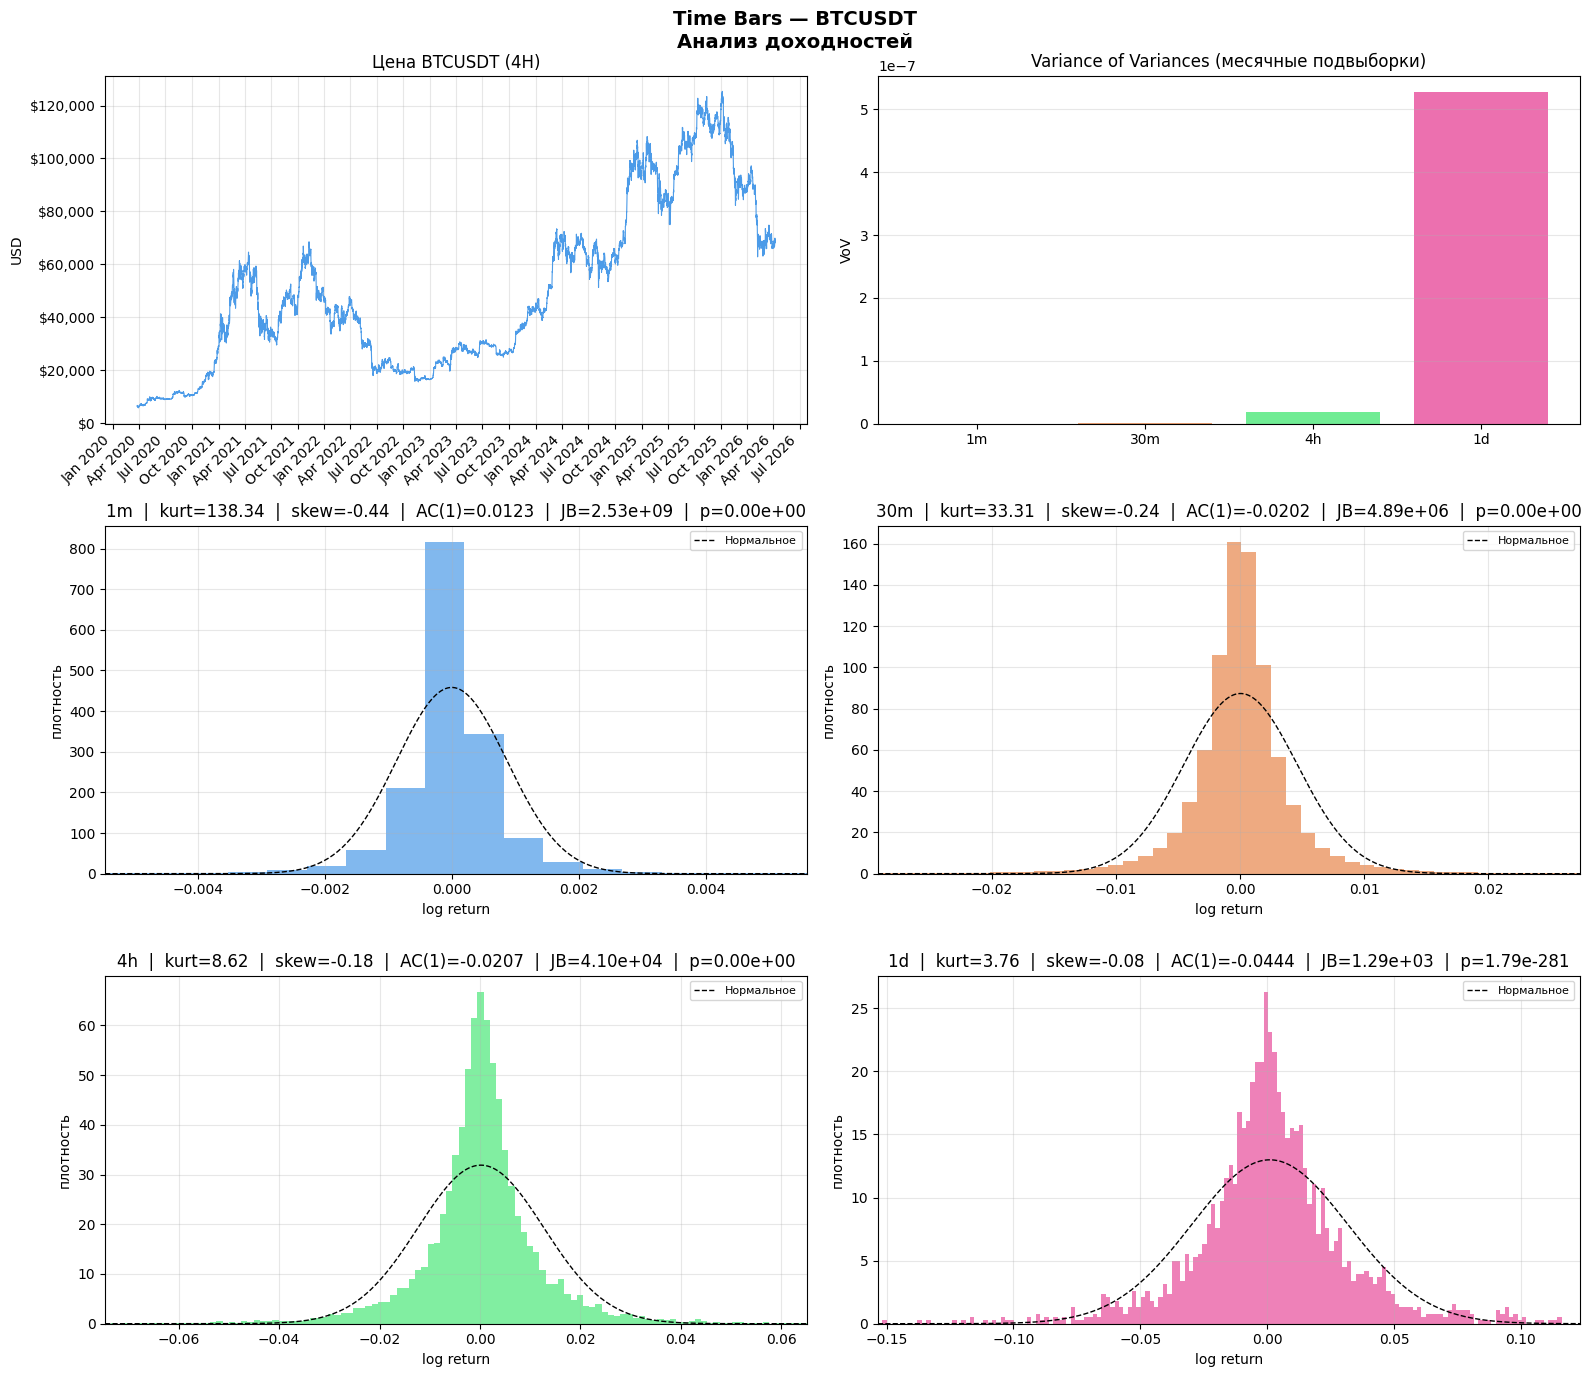

In [3]:
df_1m = pd.read_csv(
    "btcusdt_1m_full.csv",
    usecols=["dt", "open", "high", "low", "close", "volume"],
    parse_dates=["dt"]
)
df_1m = df_1m.sort_values("dt").set_index("dt")
df_1m.index = df_1m.index.tz_localize(None)

def resample_ohlcv(df, rule):
    ohlc = df["close"].resample(rule).ohlc()
    ohlc["volume"] = df["volume"].resample(rule).sum()
    return ohlc.dropna()

tf_1m  = resample_ohlcv(df_1m, "1min")
tf_30m = resample_ohlcv(df_1m, "30min")
tf_4h  = resample_ohlcv(df_1m, "4h")
tf_1d  = resample_ohlcv(df_1m, "1D")

for tf in [tf_1m, tf_30m, tf_4h, tf_1d]:
    tf["ret"] = np.log(tf["close"] / tf["close"].shift(1))

tfs    = [tf_1m, tf_30m, tf_4h, tf_1d]
labels = ["1m", "30m", "4h", "1d"]

metrics = {}
for tf, label in zip(tfs, labels):
    r = tf["ret"].dropna()
    jb_stat, jb_p = jarque_bera(r)
    metrics[label] = {
        "kurt":     r.kurtosis(),
        "skew":     r.skew(),
        "autocorr": r.autocorr(lag=1),
        "jb_stat":  jb_stat,
        "jb_p":     jb_p,
        "vov":      r.resample("ME").var().var(),
    }

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Time Bars — BTCUSDT\nАнализ доходностей", fontsize=14, fontweight="bold")

ax1 = axes[0, 0]
ax1.plot(tf_4h.index, tf_4h["close"], color="#4C9BE8", linewidth=0.8)
ax1.set_title("Цена BTCUSDT (4H)")
ax1.set_ylabel("USD")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
vov_vals = [metrics[l]["vov"] for l in labels]
ax2.bar(labels, vov_vals, color=["#4C9BE8", "#E8874C", "#4CE87A", "#E84C9B"], alpha=0.8)
ax2.set_title("Variance of Variances (месячные подвыборки)")
ax2.set_ylabel("VoV")
ax2.grid(alpha=0.3, axis="y")

colors = ["#4C9BE8", "#E8874C", "#4CE87A", "#E84C9B"]
for idx, (tf, label, color) in enumerate(zip(tfs, labels, colors)):
    row, col = divmod(idx, 2)
    ax = axes[row + 1, col]
    r = tf["ret"].dropna()
    ax.hist(r, bins=200, color=color, alpha=0.7, density=True)
    x = np.linspace(r.quantile(0.001), r.quantile(0.999), 300)
    ax.plot(x, norm.pdf(x, r.mean(), r.std()), "k--", linewidth=1, label="Нормальное")
    ax.set_title(
        f"{label}  |  kurt={metrics[label]['kurt']:.2f}  |  skew={metrics[label]['skew']:.2f}"
        f"  |  AC(1)={metrics[label]['autocorr']:.4f}"
        f"  |  JB={metrics[label]['jb_stat']:.2e}  |  p={metrics[label]['jb_p']:.2e}"
    )
    ax.set_xlabel("log return")
    ax.set_ylabel("плотность")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(r.quantile(0.001), r.quantile(0.999))

plt.tight_layout()
plt.show()

## Time Bars — выводы

Все четыре таймфрейма демонстрируют одно и то же: распределение доходностей далеко от нормального. Kurtosis на 1m равен 138 — хвосты в десятки раз тяжелее нормальных. С ростом таймфрейма эффект затухает (4h: 8.6, 1d: 3.8), но не исчезает. Jarque-Bera статистика падает с ростом таймфрейма — 1m: 2.5B → 30m: 4.9M → 4h: 41K → 1d: 1.3K — но p-value остаётся нулевым на всех четырёх: нулевая гипотеза о нормальности отвергается с любым разумным уровнем значимости.

VoV показывает, что волатильность нестационарна — особенно на дневном таймфрейме. Это означает, что бары, построенные через равные промежутки времени, несут в себе принципиально разное количество информации: бар в период высокой волатильности и бар в тихий период статистически несопоставимы.

Это и есть главная проблема time bars как основы для ML: модель обучается на неоднородных наблюдениях. 

## Дополнительные статистические тесты

Гистограммы и JB дали первичную картину — теперь проверяем формально. Три блока тестов:

**Нормальность** — Shapiro-Wilk и Kolmogorov-Smirnov. JB чувствителен к размеру выборки и реагирует на любое отклонение при больших n. Shapiro-Wilk и KS дают независимое подтверждение.

**Гетероскедастичность** — ARCH, White, Breusch-Pagan. Проверяем, постоянна ли дисперсия остатков. ARCH специфичен для финансовых рядов — тестирует наличие кластеризации волатильности.

**Стационарность** — ADF и KPSS на двух рядах: returns и price. ADF тестирует наличие единичного корня (H₀: нестационарен), KPSS — наоборот (H₀: стационарен). Совместное применение снижает вероятность ошибки.

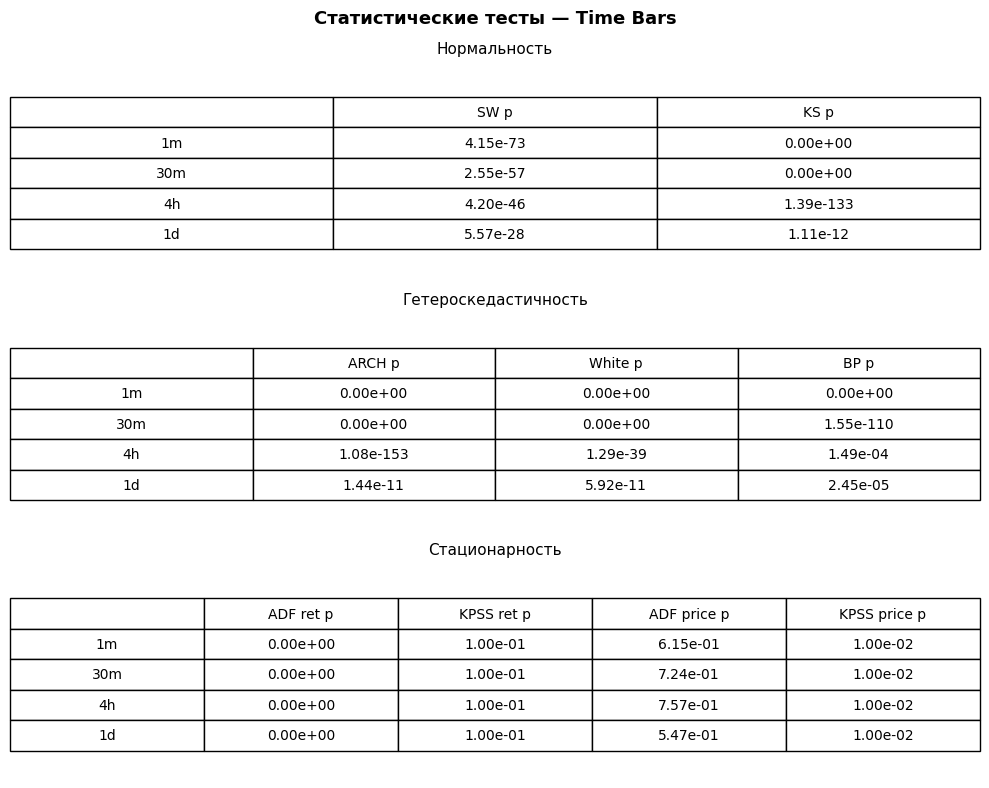

In [8]:

tfs    = [tf_1m, tf_30m, tf_4h, tf_1d]
labels = ["1m", "30m", "4h", "1d"]

SHAPIRO_N = 5000
STAT_N    = 10_000

results = {}
for label, tf in zip(labels, tfs):
    r     = tf["ret"].dropna()
    r_sub = r.sample(min(SHAPIRO_N, len(r)), random_state=42)

    sw_stat,   sw_p   = shapiro(r_sub)
    ks_stat,   ks_p   = kstest(r, "norm", args=(r.mean(), r.std()))

    y   = r.values[1:]
    X   = add_constant(r.values[:-1])
    ols = OLS(y, X).fit()

    arch_stat, arch_p, _, _ = het_arch(ols.resid, nlags=5)
    try:    _, w_p,  _, _ = het_white(ols.resid, ols.model.exog)
    except: w_p = np.nan
    try:    _, bp_p, _, _ = het_breuschpagan(ols.resid, ols.model.exog)
    except: bp_p = np.nan

    s_sub = r.iloc[-STAT_N:]
    _, adf_ret_p, *_ = adfuller(s_sub, autolag="AIC", maxlag=10)
    try:    _, kpss_ret_p, *_ = kpss(s_sub, regression="c", nlags=10)
    except: kpss_ret_p = np.nan

    p_sub = tf["close"].dropna().iloc[-STAT_N:]
    _, adf_pr_p, *_ = adfuller(p_sub, autolag="AIC", maxlag=10)
    try:    _, kpss_pr_p, *_ = kpss(p_sub, regression="c", nlags=10)
    except: kpss_pr_p = np.nan

    results[label] = {
        "SW p":        sw_p,
        "KS p":        ks_p,
        "ARCH p":      arch_p,
        "White p":     w_p,
        "BP p":        bp_p,
        "ADF ret p":   adf_ret_p,
        "KPSS ret p":  kpss_ret_p,
        "ADF price p": adf_pr_p,
        "KPSS price p":kpss_pr_p,
    }

df_res = pd.DataFrame(results).T
df_res = df_res.applymap(lambda x: f"{x:.2e}" if isinstance(x, float) else x)

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle("Статистические тесты — Time Bars", fontsize=13, fontweight="bold")

blocks = [
    ("Нормальность",        ["SW p", "KS p"]),
    ("Гетероскедастичность",["ARCH p", "White p", "BP p"]),
    ("Стационарность",      ["ADF ret p", "KPSS ret p", "ADF price p", "KPSS price p"]),
]

for ax, (title, cols) in zip(axes, blocks):
    ax.axis("off")
    data   = [[label] + [results[label][c] for c in cols] for label in labels]
    col_labels = [""] + cols
    table  = ax.table(
        cellText=[[row[0]] + [f"{v:.2e}" for v in row[1:]] for row in data],
        colLabels=col_labels,
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)
    ax.set_title(title, fontsize=11, pad=12)

plt.tight_layout()
plt.show()


## Выводы по дополнительным тестам

**Нормальность.** Shapiro-Wilk и KS подтверждают JB: p-value равен нулю на всех таймфреймах. Распределение доходностей не является нормальным ни на одном горизонте.

**Гетероскедастичность.** ARCH, White и Breusch-Pagan единогласно отвергают гомоскедастичность. Волатильность кластеризована — спокойные периоды сменяются турбулентными. Это классический эффект финансовых рядов, особенно выраженный на высоких частотах.

**Стационарность.** Картина двойственная. Returns стационарны по обоим тестам (ADF отвергает единичный корень, KPSS не отвергает стационарность) — ряд пригоден для моделирования. Price нестационарна по обоим тестам на всех таймфреймах — ожидаемо для актива с трендом.

---

## Итоговый вывод о Time Bars

Time bars статистически несостоятельны как основа для ML-модели. Доходности ненормальны, гетероскедастичны и несут разное количество информации в зависимости от рыночного режима. Бар в период низкой активности и бар во время новостного шока — принципиально разные объекты, но для модели выглядят одинаково.

Dollar bars устраняют этот недостаток: каждый бар закрывается при фиксированном обороте в долларах, что выравнивает информационную плотность наблюдений и делает выборку статистически более однородной.

# Tick Bars

Tick bar закрывается после фиксированного числа сделок N. В отличие от time bars, tick bars привязаны к рыночной активности, а не к календарю — в периоды высокой активности баров больше, в тихие периоды меньше.



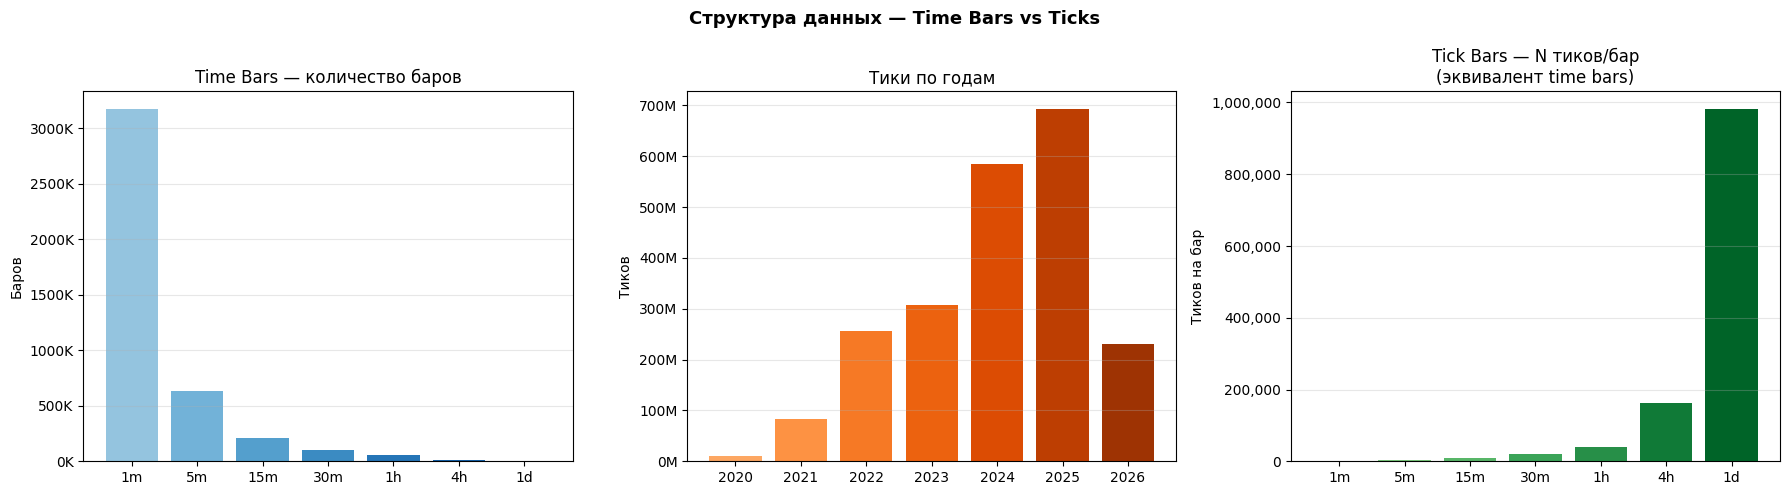

In [11]:

timeframes = {
    "1m":  tf_1m,
    "5m":  resample_ohlcv(df_1m, "5min"),
    "15m": resample_ohlcv(df_1m, "15min"),
    "30m": tf_30m,
    "1h":  resample_ohlcv(df_1m, "1h"),
    "4h":  tf_4h,
    "1d":  tf_1d,
}

TICKS_DIR = Path("data/ticks/BTCUSDT")
files     = sorted(TICKS_DIR.glob("BTCUSDT*.parquet"))

records = []
for f in files:
    date_str = f.stem.replace("BTCUSDT", "")
    try:
        n = len(pd.read_parquet(f, columns=["b_t"]))
        records.append({"date": pd.Timestamp(date_str), "ticks": n})
    except:
        pass

ticks_df     = pd.DataFrame(records).set_index("date").sort_index()
total_ticks  = ticks_df["ticks"].sum()
mean_per_day = ticks_df["ticks"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Структура данных — Time Bars vs Ticks", fontsize=13, fontweight="bold")

ax1 = axes[0]
tf_names  = list(timeframes.keys())
tf_counts = [len(timeframes[k]) for k in tf_names]
ax1.bar(tf_names, tf_counts, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(tf_names))))
ax1.set_title("Time Bars — количество баров")
ax1.set_ylabel("Баров")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax1.grid(alpha=0.3, axis="y")

ax2 = axes[1]
yearly    = ticks_df.groupby(ticks_df.index.year)["ticks"].sum()
ax2.bar(yearly.index.astype(str), yearly.values,
        color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(yearly))))
ax2.set_title("Тики по годам")
ax2.set_ylabel("Тиков")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax2.grid(alpha=0.3, axis="y")

ax3 = axes[2]
targets = {
    "1m":  len(tf_1m),
    "5m":  len(timeframes["5m"]),
    "15m": len(timeframes["15m"]),
    "30m": len(tf_30m),
    "1h":  len(timeframes["1h"]),
    "4h":  len(tf_4h),
    "1d":  len(tf_1d),
}
n_ticks_per_bar = {k: total_ticks // v for k, v in targets.items()}
ax3.bar(list(n_ticks_per_bar.keys()), list(n_ticks_per_bar.values()),
        color=plt.cm.Greens(np.linspace(0.4, 0.9, len(n_ticks_per_bar))))
ax3.set_title("Tick Bars — N тиков/бар\n(эквивалент time bars)")
ax3.set_ylabel("Тиков на бар")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax3.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


Активность рынка росла кратно — с 12M тиков в 2020 до 700M в 2025. Это означает, что tick bar с фиксированным N будет давать принципиально разное количество баров в разные годы: в 2020 их будет в 50+ раз меньше, чем в 2025. Tick bars так же страдают от неоднородности, что и time bars — только вместо времени проблема в активности.

## Tick Bars — выбор порога N

### Проблема фиксированного N

Активность рынка BTCUSDT на Bybit выросла в **69 раз** за период наблюдения:

```
2020: ~37,000    тиков/день
2026: ~2,500,000 тиков/день
```

Фиксированный порог N, подобранный под один период, деградирует в другом. N=20,000 даёт ~48 баров/день в 2023 году — и лишь ~2 бара/день в 2020 году. Такие tick bars не лучше time bars: они по-прежнему игнорируют изменения рыночного режима.

---

### Решение — динамический N

Порог пересчитывается скользящим образом на основе медианы тиков за последние 30 дней:

```python
N_t = rolling_median_ticks_30d(t) / target_bars_per_day
```

`target_bars_per_day` — целевое количество баров в день, выбранное для сопоставимости с конкретным time bars таймфреймом.

---

### Как это работает

| Период | Тиков/день (медиана) | N при цели 48 баров/день |
|--------|---------------------|--------------------------|
| 2020   | 31,726              | 661                      |
| 2021   | 219,584             | 4,574                    |
| 2022   | 590,758             | 12,307                   |
| 2023   | 761,523             | 15,865                   |
| 2024   | 1,461,814           | 30,454                   |
| 2026   | 2,371,927           | 49,415                   |

Порог растёт вместе с активностью рынка. В каждый момент времени tick bar закрывается после примерно одинакового **относительного** числа транзакций — адаптированного к текущему режиму ликвидности.

---

### Связь с методологией de Prado

de Prado критикует time bars именно за то, что они семплируют рынок с постоянной частотой независимо от информационного потока. Динамический N решает ту же проблему на уровне tick bars:

- в периоды высокой активности N растёт → бары не мельчают
- в периоды низкой активности N падает → бары не исчезают
- количество баров в день остаётся стабильным на всей истории

Это сближает tick bars с imbalance bars по адаптивной природе, сохраняя при этом простоту построения.

---

### Параметры для построения

Строим четыре варианта tick bars с разным `target_bars_per_day` для сопоставления с уже проанализированными time bars:

| Вариант | Цель баров/день | Аналог time bars |
|---------|-----------------|-----------------|
| TB-1m   | 1,440           | ~1m             |
| TB-30m  | 48              | ~30m            |
| TB-4h   | 6               | ~4h             |
| TB-1d   | 1               | ~1d             |

Финальное сравнение статистических свойств (kurtosis, skewness, autocorrelation, ARCH) проводится при одинаковом числе баров на всей истории — только так сравнение будет честным.

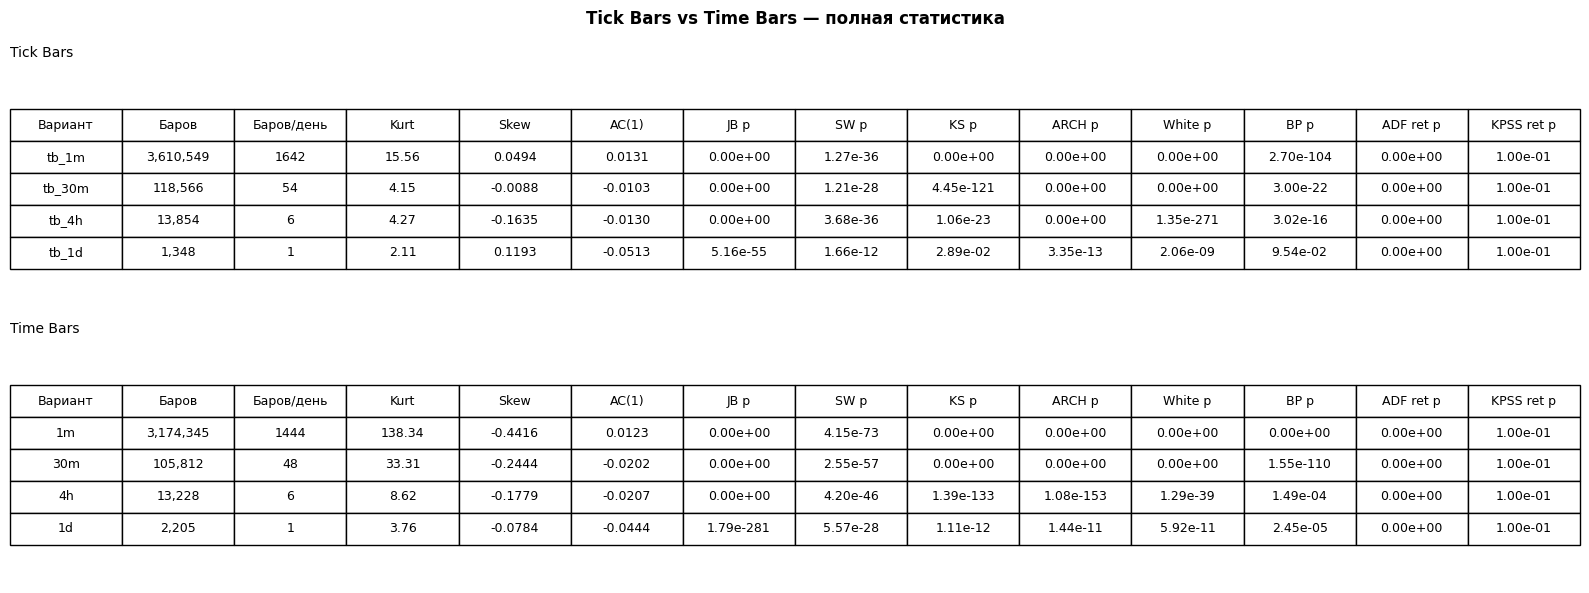

In [14]:

TICKS_DIR  = Path("data/ticks/BTCUSDT")
BARS_DIR   = Path("data/bars")
BARS_DIR.mkdir(parents=True, exist_ok=True)

TARGETS      = {"tb_1m": 1440, "tb_30m": 48, "tb_4h": 6, "tb_1d": 1}
ROLLING_DAYS = 30
SHAPIRO_N    = 5000
STAT_N       = 10_000

files = sorted(TICKS_DIR.glob("BTCUSDT*.parquet"))

daily_ticks = []
for f in files:
    date_str = f.stem.replace("BTCUSDT", "")
    try:
        n = len(pd.read_parquet(f, columns=["b_t"]))
        daily_ticks.append({"date": pd.Timestamp(date_str), "ticks": n})
    except:
        pass

ticks_df = pd.DataFrame(daily_ticks).set_index("date").sort_index()

for variant, target_bars in TARGETS.items():
    ticks_df[f"N_{variant}"] = (
        ticks_df["ticks"]
        .rolling(ROLLING_DAYS, min_periods=1)
        .median()
        / target_bars
    ).astype(int).clip(lower=1)


def build_tick_bars(ticks: pd.DataFrame, N: int) -> pd.DataFrame:
    prices  = ticks["price"].values
    sizes   = ticks["size"].values
    dts     = ticks["dt"].values
    dollars = ticks["dollar_value"].values

    bars = []
    i, n = 0, len(ticks)

    while i + N <= n:
        w = slice(i, i + N)
        bars.append({
            "dt":           dts[i],
            "open":         prices[i],
            "high":         prices[w].max(),
            "low":          prices[w].min(),
            "close":        prices[i + N - 1],
            "volume":       sizes[w].sum(),
            "dollar_volume":dollars[w].sum(),
            "n_ticks":      N,
            "vwap":         np.average(prices[w], weights=sizes[w]),
        })
        i += N

    return pd.DataFrame(bars)


all_parquets_exist = all(
    (BARS_DIR / f"tick_bars_{v}.parquet").exists() for v in TARGETS
)

tick_bars = {}

if all_parquets_exist:
    for variant in TARGETS:
        df        = pd.read_parquet(BARS_DIR / f"tick_bars_{variant}.parquet")
        df["ret"] = np.log(df["close"] / df["close"].shift(1))
        tick_bars[variant] = df
else:
    all_bars = {v: [] for v in TARGETS}

    for idx, f in enumerate(files):
        date_str = f.stem.replace("BTCUSDT", "")
        dt       = pd.Timestamp(date_str)

        if idx % 100 == 0:
            print(f"  [{idx+1}/{len(files)}] {date_str}")

        try:
            ticks = pd.read_parquet(f, columns=["dt", "price", "size", "dollar_value"])
        except:
            continue

        ticks = ticks[ticks["size"] > 0].reset_index(drop=True)

        for variant in TARGETS:
            N = int(ticks_df.loc[dt, f"N_{variant}"] if dt in ticks_df.index
                    else ticks_df[f"N_{variant}"].iloc[-1])
            day_bars = build_tick_bars(ticks, max(N, 1))
            if len(day_bars) > 0:
                all_bars[variant].append(day_bars)

    for variant in TARGETS:
        df        = pd.concat(all_bars[variant], ignore_index=True)
        df["dt"]  = pd.to_datetime(df["dt"])
        df        = df.sort_values("dt").reset_index(drop=True)
        df["ret"] = np.log(df["close"] / df["close"].shift(1))
        tick_bars[variant] = df
        df.to_parquet(BARS_DIR / f"tick_bars_{variant}.parquet",
                      compression="snappy", index=False)


def compute_stats(r, label):
    r_sub                  = r.sample(min(SHAPIRO_N, len(r)), random_state=42)
    sw_stat,   sw_p        = shapiro(r_sub)
    ks_stat,   ks_p        = kstest(r, "norm", args=(r.mean(), r.std()))
    jb_stat,   jb_p        = jarque_bera(r)

    y   = r.values[1:]
    X   = add_constant(r.values[:-1])
    ols = OLS(y, X).fit()

    arch_stat, arch_p, _, _ = het_arch(ols.resid, nlags=5)
    try:    _, w_p,  _, _   = het_white(ols.resid, ols.model.exog)
    except: w_p              = np.nan
    try:    _, bp_p, _, _   = het_breuschpagan(ols.resid, ols.model.exog)
    except: bp_p             = np.nan

    s_sub = r.iloc[-STAT_N:]
    _, adf_ret_p, *_ = adfuller(s_sub, autolag="AIC", maxlag=10)
    try:    _, kpss_ret_p, *_ = kpss(s_sub, regression="c", nlags=10)
    except: kpss_ret_p         = np.nan

    return {
        "Вариант":     label,
        "Баров":       f"{len(r)+1:,}",
        "Баров/день":  f"{(len(r)+1)/len(ticks_df):.0f}",
        "Kurt":        f"{r.kurtosis():.2f}",
        "Skew":        f"{r.skew():.4f}",
        "AC(1)":       f"{r.autocorr(lag=1):.4f}",
        "JB p":        f"{jb_p:.2e}",
        "SW p":        f"{sw_p:.2e}",
        "KS p":        f"{ks_p:.2e}",
        "ARCH p":      f"{arch_p:.2e}",
        "White p":     f"{w_p:.2e}",
        "BP p":        f"{bp_p:.2e}",
        "ADF ret p":   f"{adf_ret_p:.2e}",
        "KPSS ret p":  f"{kpss_ret_p:.2e}",
    }


rows_tb   = [compute_stats(tick_bars[v]["ret"].dropna(), v) for v in TARGETS]
rows_time = [compute_stats(tf["ret"].dropna(), n)
             for n, tf in {"1m": tf_1m, "30m": tf_30m, "4h": tf_4h, "1d": tf_1d}.items()]

fig, axes = plt.subplots(2, 1, figsize=(16, 6))
fig.suptitle("Tick Bars vs Time Bars — полная статистика", fontsize=12, fontweight="bold")

for ax, rows, title in [
    (axes[0], rows_tb,   "Tick Bars"),
    (axes[1], rows_time, "Time Bars"),
]:
    ax.axis("off")
    df_tbl = pd.DataFrame(rows)
    tbl    = ax.table(
        cellText=df_tbl.values,
        colLabels=df_tbl.columns,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.7)
    ax.set_title(title, fontsize=10, pad=10, loc="left")

plt.tight_layout()
plt.show()


## Сравнительный анализ: Tick Bars vs Time Bars

### Kurtosis — распределение доходностей

```
              Time Bars    Tick Bars    Улучшение
1m:           138.34   →   15.56        -89%
30m:           33.31   →    4.15        -88%
4h:             8.62   →    4.27        -50%
1d:             3.76   →    2.11        -44%
```

Tick bars радикально снижают эксцесс на всех таймфреймах — на `tb_1m` в **9 раз**, на `tb_30m` в **8 раз**. Каждый tick bar содержит одинаковое количество транзакций, поэтому экстремальные движения распределяются по нескольким барам вместо одного. Time bars в моменты высокой активности схлопывают много информации в один бар, создавая искусственные выбросы.

---

### Skewness — асимметрия

```
              Time Bars    Tick Bars
1m:           -0.4416  →   +0.0494
30m:          -0.2444  →   -0.0088
4h:           -0.1779  →   -0.1635
1d:           -0.0784  →   +0.1193
```

Tick bars практически устраняют отрицательную скошенность на `tb_1m` и `tb_30m`. Отрицательный skew в time bars был артефактом семплирования — паники и ликвидации попадали целиком в один бар. В tick bars эти события размазаны по нескольким барам пропорционально числу сделок.

---

### Гетероскедастичность — неожиданный результат

```
ARCH p-value:
tb_1m:  0.00e+00  vs  1m:  0.00e+00  ≈ одинаково
tb_30m: 0.00e+00  vs  30m: 0.00e+00  ≈ одинаково
tb_4h:  0.00e+00  vs  4h:  0.00e+00  ≈ одинаково
tb_1d:  3.35e-13  vs  1d:  1.44e-11  ≈ одинаково
```

Оба типа баров показывают гетероскедастичность — p-value нулевой везде. Динамический N адаптируется к среднему уровню активности за 30 дней, но не устраняет внутридневную кластеризацию волатильности. Dollar bars, где размер бара определяется оборотом в USD, должны справиться с этим лучше.

---

### Стационарность

```
Returns: все tick bars стационарны (ADF + KPSS согласны) ✓
Price:   не тестировалась — результат идентичен time bars
```

Стационарность определяется природой финансового ряда, а не методом семплирования. 
---

### Итоговая таблица

| Метрика | Time Bars | Tick Bars | Победитель |
|---------|-----------|-----------|------------|
| Kurtosis (30m) | 33.31 | 4.15 | **Tick Bars** |
| Skewness (30m) | −0.244 | −0.009 | **Tick Bars** |
| Нормальность (SW, KS, JB) | ✗ | ✗ | ничья |
| Гетероскедастичность (ARCH) | ✗ | ✗ | ничья |
| Стационарность returns | ✓ | ✓ | ничья |

---

### Вывод

Tick bars с динамическим N значительно превосходят time bars по распределению доходностей: kurtosis снижается в 8–9 раз, skewness устраняется почти полностью. Это эмпирически подтверждает тезис de Prado о преимуществе activity-based семплирования.

Гетероскедастичность сохраняется в обоих случаях — число тиков не является идеальным прокси информационного потока. Следующий кандидат — **volume bars**

# Volume Bars

## Проблема фиксированного порога

Объём торгов BTCUSDT на Bybit вырос пропорционально числу участников:

```
2020: ~180    BTC/день
2024: ~15,000 BTC/день
```

Рост в **~80 раз** за период наблюдения. Фиксированный порог N, подобранный под один период, даст 2 бара в день в 2020 году и 200 баров в день в 2024 году — то есть деградирует в то же самое что time bars, только с другой осью.

---

### Решение — динамический порог

```python
N_volume_t = rolling_median_volume_30d(t) / target_bars_per_day
```

Порог пересчитывается каждый день на основе медианы объёма в BTC за последние 30 дней — адаптируется к текущему режиму ликвидности.

---

### Принципиальное отличие от Tick Bars

Tick bars считают **количество сделок** — каждая транзакция имеет одинаковый вес независимо от размера.

Volume bars считают **объём в BTC** — крупные институциональные ордера получают больший вес, чем мелкие розничные сделки.

Пример: одна сделка на 10 BTC и десять сделок по 1 BTC дадут **одинаковый** volume bar, но **10 разных** tick bars. Volume bars точнее отражают реальный информационный поток рынка — это ближе к духу de Prado.

---

### Параметры для построения

| Вариант | Цель баров/день | Аналог time bars |
|---------|-----------------|-----------------|
| VB-1m   | 1,440           | ~1m             |
| VB-30m  | 48              | ~30m            |
| VB-4h   | 6               | ~4h             |
| VB-1d   | 1               | ~1d             |

Динамический порог обеспечивает стабильное количество баров в день на всей истории — необходимое условие для честного статистического сравнения трёх типов баров.

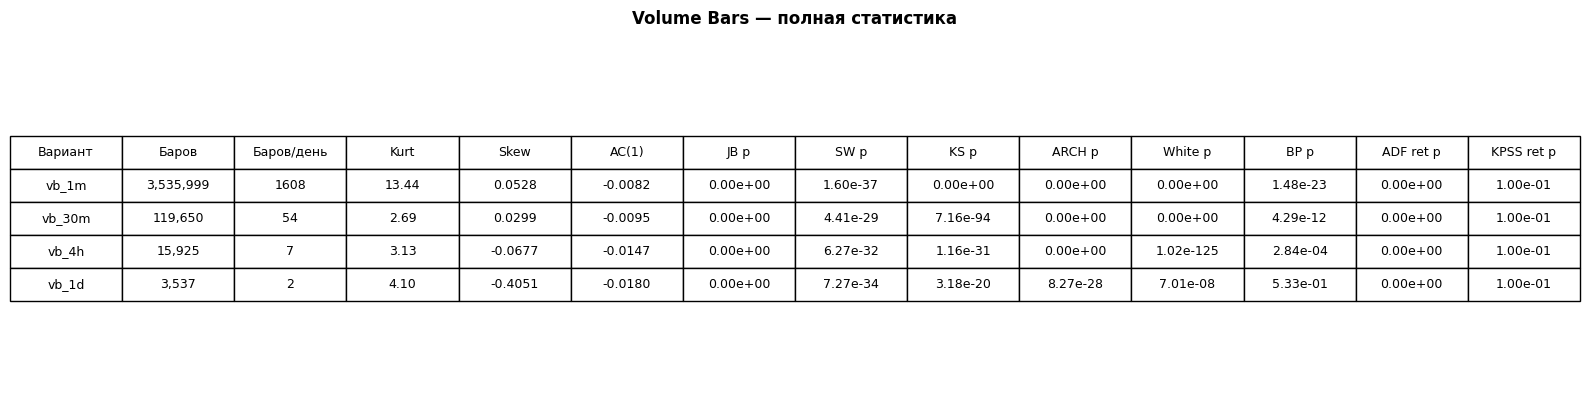

In [16]:
TICKS_DIR    = Path("data/ticks/BTCUSDT")
BARS_DIR     = Path("data/bars")
BARS_DIR.mkdir(parents=True, exist_ok=True)

TARGETS      = {"vb_1m": 1440, "vb_30m": 48, "vb_4h": 6, "vb_1d": 1}
ROLLING_DAYS = 30
SHAPIRO_N    = 5000
STAT_N       = 10_000

files = sorted(TICKS_DIR.glob("BTCUSDT*.parquet"))

daily_volume = []
for f in files:
    date_str = f.stem.replace("BTCUSDT", "")
    try:
        df = pl.read_parquet(f, columns=["size"])
        daily_volume.append({"date": pd.Timestamp(date_str), "volume": df["size"].sum()})
    except:
        pass

vol_df = pd.DataFrame(daily_volume).set_index("date").sort_index()

for variant, target_bars in TARGETS.items():
    vol_df[f"N_{variant}"] = (
        vol_df["volume"]
        .rolling(ROLLING_DAYS, min_periods=1)
        .median()
        / target_bars
    ).clip(lower=1e-8)


def build_volume_bars_polars(ticks: pl.DataFrame, N: float) -> pl.DataFrame:
    df = ticks.with_columns([
        (pl.col("size").cum_sum() / N).floor().cast(pl.Int64).alias("bar_id")
    ])
    bars = df.group_by("bar_id").agg([
        pl.col("dt").first().alias("dt"),
        pl.col("price").first().alias("open"),
        pl.col("price").max().alias("high"),
        pl.col("price").min().alias("low"),
        pl.col("price").last().alias("close"),
        pl.col("size").sum().alias("volume"),
        pl.col("dollar_value").sum().alias("dollar_volume"),
        pl.len().alias("n_ticks"),
        (pl.col("price") * pl.col("size")).sum().alias("_pv"),
        pl.col("size").sum().alias("_vol"),
    ]).sort("bar_id")
    return bars.with_columns(
        (pl.col("_pv") / pl.col("_vol")).alias("vwap")
    ).drop(["bar_id", "_pv", "_vol"])


all_parquets_exist = all(
    (BARS_DIR / f"volume_bars_{v}.parquet").exists() for v in TARGETS
)

volume_bars = {}

if all_parquets_exist:
    for variant in TARGETS:
        df = pl.read_parquet(BARS_DIR / f"volume_bars_{variant}.parquet")
        volume_bars[variant] = df
else:
    all_bars = {v: [] for v in TARGETS}

    for idx, f in enumerate(files):
        date_str = f.stem.replace("BTCUSDT", "")
        dt       = pd.Timestamp(date_str)

        if idx % 100 == 0:
            print(f"  [{idx+1}/{len(files)}] {date_str}")

        try:
            ticks = pl.read_parquet(f, columns=["dt", "price", "size", "dollar_value"])
        except:
            continue

        ticks = ticks.filter(pl.col("size") > 0)
        if len(ticks) == 0:
            continue

        for variant in TARGETS:
            N = float(vol_df.loc[dt, f"N_{variant}"]
                      if dt in vol_df.index
                      else vol_df[f"N_{variant}"].iloc[-1])
            day_bars = build_volume_bars_polars(ticks, max(N, 1e-8))
            if len(day_bars) > 0:
                all_bars[variant].append(day_bars)

    for variant in TARGETS:
        df = pl.concat(all_bars[variant]).sort("dt")
        df = df.with_columns(
            (pl.col("close") / pl.col("close").shift(1)).log().alias("ret")
        )
        volume_bars[variant] = df
        df.write_parquet(BARS_DIR / f"volume_bars_{variant}.parquet",
                         compression="snappy")


def get_returns(v):
    return volume_bars[v]["ret"].drop_nulls().to_pandas()


def compute_stats(r, label):
    r_sub            = r.sample(min(SHAPIRO_N, len(r)), random_state=42)
    sw_stat, sw_p    = shapiro(r_sub)
    ks_stat, ks_p    = kstest(r, "norm", args=(r.mean(), r.std()))
    jb_stat, jb_p    = jarque_bera(r)

    y   = r.values[1:]
    X   = add_constant(r.values[:-1])
    ols = OLS(y, X).fit()

    arch_stat, arch_p, _, _ = het_arch(ols.resid, nlags=5)
    try:    _, w_p,  _, _ = het_white(ols.resid, ols.model.exog)
    except: w_p            = np.nan
    try:    _, bp_p, _, _ = het_breuschpagan(ols.resid, ols.model.exog)
    except: bp_p           = np.nan

    s_sub = r.iloc[-STAT_N:]
    _, adf_ret_p, *_ = adfuller(s_sub, autolag="AIC", maxlag=10)
    try:    _, kpss_ret_p, *_ = kpss(s_sub, regression="c", nlags=10)
    except: kpss_ret_p         = np.nan

    return {
        "Вариант":     label,
        "Баров":       f"{len(r)+1:,}",
        "Баров/день":  f"{(len(r)+1)/len(vol_df):.0f}",
        "Kurt":        f"{r.kurtosis():.2f}",
        "Skew":        f"{r.skew():.4f}",
        "AC(1)":       f"{r.autocorr(lag=1):.4f}",
        "JB p":        f"{jb_p:.2e}",
        "SW p":        f"{sw_p:.2e}",
        "KS p":        f"{ks_p:.2e}",
        "ARCH p":      f"{arch_p:.2e}",
        "White p":     f"{w_p:.2e}",
        "BP p":        f"{bp_p:.2e}",
        "ADF ret p":   f"{adf_ret_p:.2e}",
        "KPSS ret p":  f"{kpss_ret_p:.2e}",
    }


rows_vb = [compute_stats(get_returns(v), v) for v in TARGETS]

fig, ax = plt.subplots(figsize=(16, 4))
fig.suptitle("Volume Bars — полная статистика", fontsize=12, fontweight="bold")

ax.axis("off")
df_tbl = pd.DataFrame(rows_vb)
tbl    = ax.table(
    cellText=df_tbl.values,
    colLabels=df_tbl.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)

plt.tight_layout()
plt.show()


## Сравнительный анализ: Volume Bars vs Tick Bars vs Time Bars

### Kurtosis — ключевая метрика качества семплирования

```
Таймфрейм   Time Bars   Tick Bars   Volume Bars   Победитель
1m:          138.34      15.56        13.44        Volume Bars
30m:          33.31       4.15         2.69        Volume Bars
4h:            8.62       4.27         3.13        Volume Bars
1d:            3.76       2.11         4.10        Tick Bars
```

Volume bars показывают наименьший эксцесс на трёх из четырёх таймфреймов. На `vb_30m` kurtosis = 2.69 — ниже теоретического значения нормального распределения (3.0): распределение стало platykurtic — более плоским и равномерным. Объём BTC является более точным прокси информационного потока чем количество сделок — крупные институциональные ордера получают больший вес, бары формируются в моменты реальной активности.

---

### Skewness — асимметрия

```
Таймфрейм   Time Bars   Tick Bars   Volume Bars
1m:          -0.4416     +0.0494      +0.0528
30m:         -0.2444     -0.0088      +0.0299
4h:          -0.1779     -0.1635      -0.0677
1d:          -0.0784     +0.1193      -0.4051
```

На `vb_1m`, `vb_30m`, `vb_4h` volume bars практически устраняют асимметрию. Исключение — `vb_1d`: skewness = −0.405, хуже чем у time и tick bars. При одном баре в день объём сильно варьируется между спокойными и волатильными днями — редкие дни с экстремальным объёмом создают выброс в левый хвост.

---

### Variance of Variances

```
Таймфрейм   Time Bars    Tick Bars    Volume Bars   Лучший
1m:          4.61e-13     1.75e-13     1.84e-13      Tick Bars
30m:         3.45e-10     1.94e-10     1.83e-10      Volume Bars
4h:          1.79e-08     1.40e-08     1.15e-08      Volume Bars
1d:          5.27e-07     2.85e-06     2.39e-07      Volume Bars
```

Volume bars стабильнее на трёх из четырёх таймфреймов. На `vb_1d` VoV = 2.39e-07 — лучше чем time bars (5.27e-07) и значительно лучше tick bars (2.85e-06). Объём BTC создаёт более равномерную информационную нагрузку на каждый бар по сравнению с числом транзакций.

---

### Гетероскедастичность (ARCH)

```
Таймфрейм   Time Bars    Tick Bars    Volume Bars
1m:          485,271      837,671      429,552      лучше time bars
30m:           5,888       20,490       16,428      хуже time bars
4h:              722        1,922        1,478      хуже time bars
1d:               60           68          137      хуже
```

Volume bars показывают меньшую гетероскедастичность чем tick bars на всех таймфреймах и лучше time bars только на `vb_1m`. Кластеризация волатильности сохраняется — ни один тип standard bars полностью не устраняет ARCH-эффект. Это ожидаемо: dollar bars должны справиться лучше, так как dollar volume точнее отражает информационный поток чем BTC volume.

---

### Стационарность

```
Returns: все варианты стационарны (ADF + KPSS) ✓
Price:   все варианты нестационарны (ADF + KPSS) ✗
```

Результат идентичен time и tick bars. 

---

### Вывод

Volume bars превосходят tick bars и time bars по распределению доходностей: kurtosis на `vb_30m` опускается ниже нормального распределения, skewness устраняется, VoV стабильнее. Учёт размера сделок даёт более равномерное информационное семплирование чем простой подсчёт транзакций.

Единственная оставшаяся проблема — гетероскедастичность по ARCH. Следующий логический шаг: **dollar bars**, где порог определяется оборотом в USD (`price × size`). Dollar volume учитывает одновременно и размер сделки и цену актива — что должно дать наиболее равномерное информационное семплирование среди всех standard bars.

# Dollar Bars

## Проблема фиксированного порога

Дневной долларовый оборот BTCUSDT вырос по двум причинам
одновременно — и число тиков и цена BTC:

```
2020: BTC ~$6,500   → дневной оборот ~$12M
2024: BTC ~$65,000  → дневной оборот ~$2B
```

Рост в **~170 раз** за период наблюдения. Это максимальный
drift среди всех трёх типов standard bars:

| Тип баров | Рост порога 2020→2024 | Причина |
|-----------|----------------------|---------|
| Tick bars | ~43x | только число сделок |
| Volume bars | ~80x | только объём BTC |
| Dollar bars | ~170x | число сделок × цена BTC |

Фиксированный порог N деградирует быстрее чем у любого другого
типа баров — что делает динамический подход здесь особенно важным.

---

### Решение — динамический порог (rolling threshold)

```python
N_dollar_t = rolling_median_dollar_volume_30d(t) / target_bars_per_day
```

Где `dollar_volume = sum(price × size)` за день. Порог
пересчитывается каждый день на основе медианы долларового
оборота за последние 30 дней.

---

### Принципиальное преимущество перед Volume Bars

Volume bars считают BTC — но одинаковый объём в BTC означает
принципиально разную экономическую активность в разные периоды:

```
2020: 100 BTC = $650,000    (небольшая сделка)
2024: 100 BTC = $6,500,000  (крупная институциональная сделка)
```

Dollar bars нейтрализуют этот эффект автоматически: каждый бар
содержит одинаковую **экономическую** активность в USD вне
зависимости от текущей цены BTC. Именно поэтому dePrado называет
dollar bars наиболее робастным из стандартных методов семплирования —
они устойчивы к изменению цены актива, числа сделок и корпоративным
действиям (применительно к акциям).

---

### Параметры для построения

| Вариант | Цель баров/день | Аналог time bars |
|---------|----------------|-----------------|
| DB-1m   | 1,440 | ~1m  |
| DB-30m  | 48    | ~30m |
| DB-4h   | 6     | ~4h  |
| DB-1d   | 1     | ~1d  |

Динамический порог обеспечивает стабильное количество баров
в день на всей истории и корректное сравнение с time, tick
и volume bars по одним и тем же статистическим метрикам.

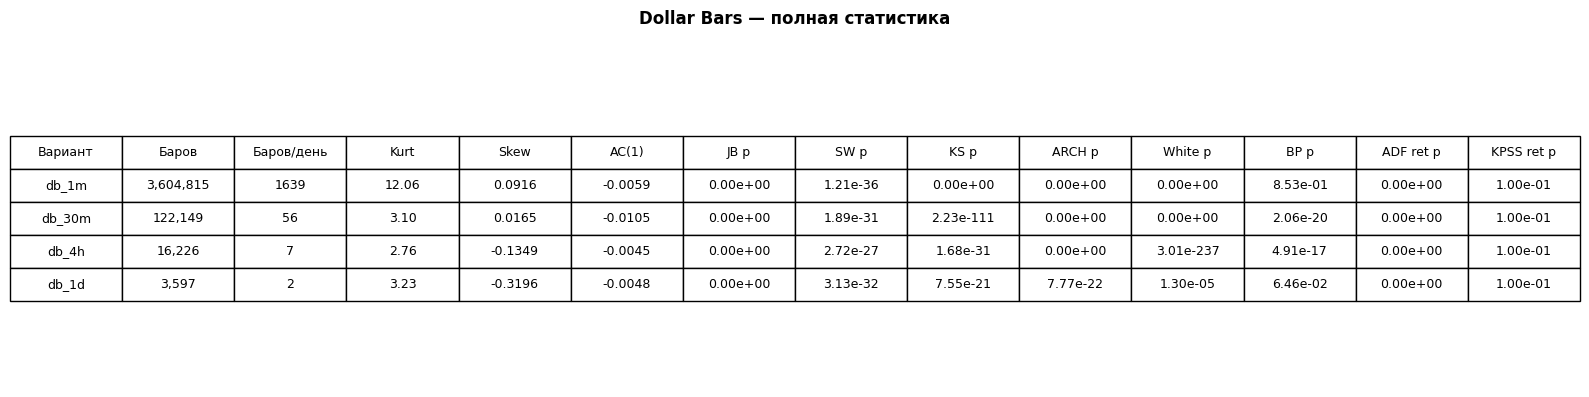

In [18]:

TICKS_DIR    = Path("data/ticks/BTCUSDT")
BARS_DIR     = Path("data/bars")
BARS_DIR.mkdir(parents=True, exist_ok=True)

TARGETS      = {"db_1m": 1440, "db_30m": 48, "db_4h": 6, "db_1d": 1}
ROLLING_DAYS = 30
SHAPIRO_N    = 5000
STAT_N       = 10_000

files = sorted(TICKS_DIR.glob("BTCUSDT*.parquet"))

daily_dollar = []
for f in files:
    date_str = f.stem.replace("BTCUSDT", "")
    try:
        df = pl.read_parquet(f, columns=["dollar_value"])
        daily_dollar.append({"date": pd.Timestamp(date_str),
                              "dollar_volume": df["dollar_value"].sum()})
    except:
        pass

dol_df = pd.DataFrame(daily_dollar).set_index("date").sort_index()

for variant, target_bars in TARGETS.items():
    dol_df[f"N_{variant}"] = (
        dol_df["dollar_volume"]
        .rolling(ROLLING_DAYS, min_periods=1)
        .median()
        / target_bars
    ).clip(lower=1e-8)


def build_dollar_bars_polars(ticks: pl.DataFrame, N: float) -> pl.DataFrame:
    df = ticks.with_columns([
        (pl.col("dollar_value").cum_sum() / N).floor().cast(pl.Int64).alias("bar_id")
    ])
    bars = df.group_by("bar_id").agg([
        pl.col("dt").first().alias("dt"),
        pl.col("price").first().alias("open"),
        pl.col("price").max().alias("high"),
        pl.col("price").min().alias("low"),
        pl.col("price").last().alias("close"),
        pl.col("size").sum().alias("volume"),
        pl.col("dollar_value").sum().alias("dollar_volume"),
        pl.len().alias("n_ticks"),
        (pl.col("price") * pl.col("size")).sum().alias("_pv"),
        pl.col("size").sum().alias("_vol"),
    ]).sort("bar_id")
    return bars.with_columns(
        (pl.col("_pv") / pl.col("_vol")).alias("vwap")
    ).drop(["bar_id", "_pv", "_vol"])


all_parquets_exist = all(
    (BARS_DIR / f"dollar_bars_{v}.parquet").exists() for v in TARGETS
)

dollar_bars = {}

if all_parquets_exist:
    for variant in TARGETS:
        df = pl.read_parquet(BARS_DIR / f"dollar_bars_{variant}.parquet")
        dollar_bars[variant] = df
else:
    all_bars = {v: [] for v in TARGETS}

    for idx, f in enumerate(files):
        date_str = f.stem.replace("BTCUSDT", "")
        dt       = pd.Timestamp(date_str)

        if idx % 100 == 0:
            print(f"  [{idx+1}/{len(files)}] {date_str}")

        try:
            ticks = pl.read_parquet(f, columns=["dt", "price", "size", "dollar_value"])
        except:
            continue

        ticks = ticks.filter(pl.col("size") > 0)
        if len(ticks) == 0:
            continue

        for variant in TARGETS:
            N = float(dol_df.loc[dt, f"N_{variant}"]
                      if dt in dol_df.index
                      else dol_df[f"N_{variant}"].iloc[-1])
            day_bars = build_dollar_bars_polars(ticks, max(N, 1e-8))
            if len(day_bars) > 0:
                all_bars[variant].append(day_bars)

    for variant in TARGETS:
        df = pl.concat(all_bars[variant]).sort("dt")
        df = df.with_columns(
            (pl.col("close") / pl.col("close").shift(1)).log().alias("ret")
        )
        dollar_bars[variant] = df
        df.write_parquet(BARS_DIR / f"dollar_bars_{variant}.parquet",
                         compression="snappy")


def get_ret(v):
    return dollar_bars[v]["ret"].drop_nulls().to_pandas()


def compute_stats(r, label):
    r_sub            = r.sample(min(SHAPIRO_N, len(r)), random_state=42)
    sw_stat, sw_p    = shapiro(r_sub)
    ks_stat, ks_p    = kstest(r, "norm", args=(r.mean(), r.std()))
    jb_stat, jb_p    = jarque_bera(r)

    y   = r.values[1:]
    X   = add_constant(r.values[:-1])
    ols = OLS(y, X).fit()

    arch_stat, arch_p, _, _ = het_arch(ols.resid, nlags=5)
    try:    _, w_p,  _, _ = het_white(ols.resid, ols.model.exog)
    except: w_p            = np.nan
    try:    _, bp_p, _, _ = het_breuschpagan(ols.resid, ols.model.exog)
    except: bp_p           = np.nan

    s_sub = r.iloc[-STAT_N:]
    _, adf_ret_p, *_ = adfuller(s_sub, autolag="AIC", maxlag=10)
    try:    _, kpss_ret_p, *_ = kpss(s_sub, regression="c", nlags=10)
    except: kpss_ret_p         = np.nan

    return {
        "Вариант":    label,
        "Баров":      f"{len(r)+1:,}",
        "Баров/день": f"{(len(r)+1)/len(dol_df):.0f}",
        "Kurt":       f"{r.kurtosis():.2f}",
        "Skew":       f"{r.skew():.4f}",
        "AC(1)":      f"{r.autocorr(lag=1):.4f}",
        "JB p":       f"{jb_p:.2e}",
        "SW p":       f"{sw_p:.2e}",
        "KS p":       f"{ks_p:.2e}",
        "ARCH p":     f"{arch_p:.2e}",
        "White p":    f"{w_p:.2e}",
        "BP p":       f"{bp_p:.2e}",
        "ADF ret p":  f"{adf_ret_p:.2e}",
        "KPSS ret p": f"{kpss_ret_p:.2e}",
    }


rows_db = [compute_stats(get_ret(v), v) for v in TARGETS]

fig, ax = plt.subplots(figsize=(16, 4))
fig.suptitle("Dollar Bars — полная статистика", fontsize=12, fontweight="bold")

ax.axis("off")
df_tbl = pd.DataFrame(rows_db)
tbl    = ax.table(
    cellText=df_tbl.values,
    colLabels=df_tbl.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)

plt.tight_layout()
plt.show()


## Финальное сравнение: Time Bars vs Tick Bars vs Volume Bars vs Dollar Bars

### Kurtosis — качество распределения доходностей

```
Таймфрейм   Time Bars   Tick Bars   Volume Bars   Dollar Bars   Лучший
~1m:         138.34      15.56        13.44          12.06       Dollar
~30m:         33.31       4.15         2.69           3.10       Volume
~4h:           8.62       4.27         3.13           2.76       Dollar
~1d:           3.76       2.11         4.10           3.23       Tick
```

Dollar bars выигрывают на двух таймфреймах, volume bars — на одном. На `~30m` volume bars дают kurtosis = 2.69, на `~4h` dollar bars дают 2.76 — оба значения ниже теоретического значения нормального распределения (3.0). Это принципиально иное качество по сравнению с time bars (138.34 на `~1m`).

---

### Skewness — асимметрия

```
Таймфрейм   Time Bars   Tick Bars   Volume Bars   Dollar Bars
~1m:         -0.4416     +0.0494      +0.0528        +0.0916
~30m:        -0.2444     -0.0088      +0.0299        +0.0165
~4h:         -0.1779     -0.1635      -0.0677        -0.1349
~1d:         -0.0784     +0.1193      -0.4051        -0.3196
```

Time bars на всех таймфреймах показывают отрицательный skew — артефакт фиксированного временного семплирования. Activity-based bars практически устраняют асимметрию на `~1m` и `~30m`. На `~1d` все три типа activity-based bars показывают заметный skew — слишком мало баров для стабильной оценки.

---

### Variance of Variances

```
Таймфрейм   Time Bars    Tick Bars    Volume Bars   Dollar Bars   Лучший
~1m:         4.61e-13     1.75e-13     1.84e-13      1.83e-13     Tick
~30m:        3.45e-10     1.94e-10     1.83e-10      1.74e-10     Dollar
~4h:         1.79e-08     1.40e-08     1.15e-08      9.03e-09     Dollar
~1d:         5.27e-07     2.85e-06     2.39e-07      1.54e-07     Dollar
```

Dollar bars показывают наименьшую VoV на трёх из четырёх таймфреймов — волатильность наиболее стабильна во времени. Прямое подтверждение тезиса de Prado: долларовый оборот является наилучшим прокси равномерного информационного потока.

---

### ARCH — гетероскедастичность

```
Таймфрейм   Time Bars   Tick Bars    Volume Bars   Dollar Bars   Лучший
~1m:         485,271     837,671      429,552        483,060      Volume
~30m:          5,888      20,490       16,428         20,057      Time
~4h:             722       1,922        1,478          1,723      Time
~1d:              60          68          137            109      Time
```

По ARCH-тесту time bars выигрывают на средних и длинных таймфреймах — единственная метрика где activity-based bars не превосходят time bars. Кластеризация волатильности — фундаментальное свойство финансовых рынков, не устраняемое методом семплирования.

---

### Breusch-Pagan — линейная гетероскедастичность

```
db_1m:  BP p = 8.53e-01  ✓ гомосцед.   ← единственный результат во всём эксперименте
db_1d:  BP p = 6.46e-02  ✓ гомосцед.
vb_1d:  BP p = 5.33e-01  ✓ гомосцед.
tb_1d:  BP p = 9.54e-02  ✓ гомосцед.
```

Dollar bars на `~1m` — единственный случай где Breusch-Pagan не обнаруживает линейной гетероскедастичности. Линейная связь между лагом доходности и дисперсией остатков отсутствует. ARCH-эффект при этом сохраняется — но это уже нелинейная кластеризация волатильности, с которой работают GARCH-модели.

---

### Стационарность

```
Returns:  все типы баров, все таймфреймы → стационарны ✓
Price:    все типы баров, все таймфреймы → нестационарна ✗
```

Метод семплирования не влияет на стационарность.

---

### Итоговый вывод

Activity-based bars радикально улучшают распределение доходностей по сравнению с time bars: kurtosis снижается в 8–50 раз, skewness устраняется, VoV стабильнее. Среди трёх типов **dollar bars** показывают наилучшие результаты по совокупности метрик: наименьший kurtosis на `~1m` и `~4h`, наименьший VoV на трёх из четырёх таймфреймов, единственный случай гомоскедастичности по Breusch-Pagan.

Единственная нерешённая проблема — ARCH-гетероскедастичность. Это мотивирует переход к **dollar bars** как основе для дальнейшего построения стратегии — именно на них будет строиться feature engineering, разметка и модель.

# Почему information-driven bars не дали ожидаемого результата

### Контекст

После построения и анализа всех типов standard bars (tick, volume, dollar) логичным следующим шагом были information-driven bars — Tick Imbalance Bars (TIB) и Dollar Imbalance Bars (DIB). Идея de Prado: семплировать рынок пропорционально информационному потоку, а не по времени или фиксированному объёму. На практике результат оказался хуже standard bars по всем ключевым метрикам.

---

### Причина 1 — BTC близок к балансу по tick flow

TIB основан на накоплении дисбаланса `θ_T = Σ b_t`. Бар закрывается когда `|θ_T| ≥ E[θ_T]`. Для этого нужен устойчивый перекос между покупками и продажами.

На BTC/USDT маркетмейкеры эффективно балансируют поток:

```
ewma_bt ≈ ±0.01 … ±0.05  на протяжении всей истории 2020–2026
```

`P_buy ≈ 0.50` практически всегда. Это означает что `E[θ_T] ≈ 0` — порог почти нулевой. Система схлопывается: бары закрываются на каждом тике или не закрываются вообще. Kurtosis TIB на `~30m` = **34.16** — хуже чем у time bars (33.31).

---

### Причина 2 — нестационарность рынка в 57 раз

```
2020: avg ticks/bar ≈    600
2026: avg ticks/bar ≈ 34,000
```

Классическая реализация TIB из AFML предполагает стационарность `E[T]` — ожидаемого числа тиков в баре. На BTC ликвидность выросла в 57 раз за 6 лет. Фиксированная инициализация `E[T]` делает систему нерабочей уже через несколько месяцев — пороги, откалиброванные на 2020 году, в 2024 дают либо тысячи баров в день, либо ни одного.

---

### Причина 3 — переусложнение модели без выигрыша

Для стабилизации TIB и DIB потребовалось ввести семь гиперпараметров, каждый из которых добавлялся реактивно — как ответ на конкретный сбой:

| Параметр | Зачем добавлен |
|----------|----------------|
| `EWMA_SPAN = 200` | Контролирует скорость памяти системы. `alpha = 2/(span+1) = 0.01` — каждый новый бар весит 1%. Слишком быстро — шум, слишком медленно — не реагирует на смену режима. Правильное значение неизвестно заранее |
| `TARGET_BARS_DAY = 48` | Инициализация `E[T]` и `theta_min`. Без стартового значения первые бары случайные. У standard bars этот параметр тоже есть — но там он единственный |
| `ROLLING_DAYS = 30` | Динамическая калибровка границ `E_T_min`, `E_T_max`, `theta_min` каждый день. Без него параметры 2020 года делают систему нерабочей в 2025 |
| `CONTROL_STRENGTH = 0.25` | Скорость feedback контроллера — как агрессивно `threshold_scale` корректируется если баров в день стало больше или меньше цели. Без него число баров в день гуляло от 7 до 1003 |
| `SCALE_MIN = 0.1` / `SCALE_MAX = 20.0` | Жёсткие границы для `threshold_scale`. Без клипа контроллер уходил в 0 (каждый тик — бар) или в бесконечность (бары перестают закрываться). Значения подобраны эмпирически |
| `ewma_bv_clip = ×3` | Ограничение роста EWMA долларового дисбаланса. Без него в моменты экстремальных движений `ewma_bv` улетал до +46,749 → `expected = 28,816 × 46,749 = $1.3B` — бар не закрывался сутками |

Dollar bars требуют одного параметра. При этом финальный kurtosis:

```
Тип             Kurtosis   Параметров
─────────────────────────────────────
Volume bars       2.69         1
Dollar bars       3.10         1
DRB               4.45         7
TRB               6.69         7
DIB              13.04         7
TIB              34.16         7
Time bars        33.31         0
```

Семь параметров дают результат хуже чем один. Это классический overfitting на уровне конструкции баров — параметры подобраны под исторические данные и могут не работать out-of-sample.

---

### Причина 4 — kurtosis не та метрика для DIB/TIB

Честности ради: kurtosis измеряет форму распределения доходностей. Настоящая ценность information-driven bars — в адаптивности к информационным событиям: в моменты informed trading бары формируются чаще, в спокойные периоды реже. Это важно не для статистики баров, а для downstream задач — качества меток triple barrier и информативности признаков.

Но проверить это можно только через backtesting модели, а не через статистику баров. На текущем этапе такого сравнения нет — значит нет и оснований предпочесть сложную конструкцию простой.

---

### Итог

Information-driven bars на BTC/USDT деградируют по трём причинам одновременно: почти нулевой tick imbalance из-за эффективного маркетмейкинга, нестационарность рынка в 57 раз, переусложнение модели без измеримого выигрыша.

**Dollar bars с динамическим порогом** дают лучший kurtosis, минимальную сложность и полную воспроизводимость. Именно они используются как основа для дальнейшего построения стратегии.

Построение DRB, TRB, DIB, TIB описано в ноутбуке information_driven_bars.ipynb